# The G/G/1 Queue

A **G/G/1 queue** has one server, one line, and first come, first served. The name is
**Kendall's notation**: **G**eneral (any) distribution for the time between arrivals,
**G**eneral distribution for the service times, and **1** server.

| Class | Arrivals | Service |
|---|---|---|
| `GG1(interarrival_dist, service_dist)` | any distribution | any distribution |
| `MG1(arrival_rate, service_dist)` | Poisson (exponential gaps) | any distribution |
| `GM1(interarrival_dist, service_rate)` | any distribution | exponential |

`X[n]` is how long customer `n` waits in line, not counting their own service. Customers are
numbered `0, 1, 2, ...` in arrival order, so a path is indexed by *customer* rather than by
clock time, and customer 0 arrives to an empty system so `X[0]` is always 0. Each wait comes
from the one before it by **Lindley's recursion**, `W[n+1] = max(W[n] + S[n] - A[n+1], 0)`:
a new customer waits for whatever is left of the customer ahead of them, or not at all if the
server went idle in between.

In [1]:
from symbulate import *

## `GG1` -- any arrivals, any service

Hand it two distributions: one for the gaps between arrivals, one for the service times.
`utilization` is the fraction of time the server is busy -- the queue settles down when it is
below 1, and grows without bound when it is not.

In [2]:
queue = GG1(interarrival_dist=Exponential(rate=1), service_dist=Uniform(a=0, b=1))
print("utilization:", queue.utilization)

path = queue.sim(1)
[round(path[n], 2) for n in range(10)]  # what the first ten customers waited

utilization: 0.5


[Index Result
 0     0.0,
 Index Result
 0     0.26,
 Index Result
 0     0.12,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.0,
 Index Result
 0     0.45,
 Index Result
 0     0.59,
 Index Result
 0     0.0]

Each draw is a whole sequence of waiting times, so simulate and plot sample paths as you
would for any other random process.

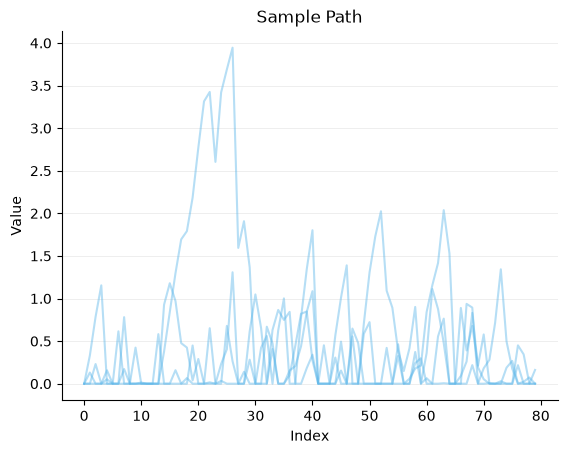

In [3]:
queue.sim(4).plot(tmin=0, tmax=80)

## `MG1` -- Poisson arrivals, any service

Give an arrival *rate* instead of a distribution and the gaps between arrivals are
Exponential, so customers arrive as a Poisson process.

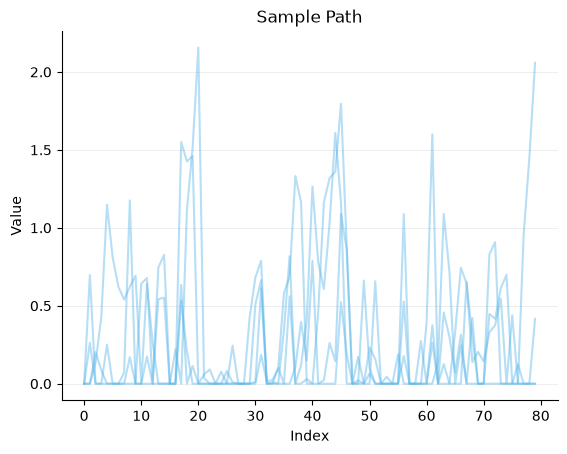

In [4]:
mg1 = MG1(arrival_rate=1, service_dist=Gamma(shape=2, rate=4))
mg1.sim(4).plot(tmin=0, tmax=80)

## `GM1` -- any arrivals, exponential service

The other way round: give a service *rate*, and describe the arrivals however you like.

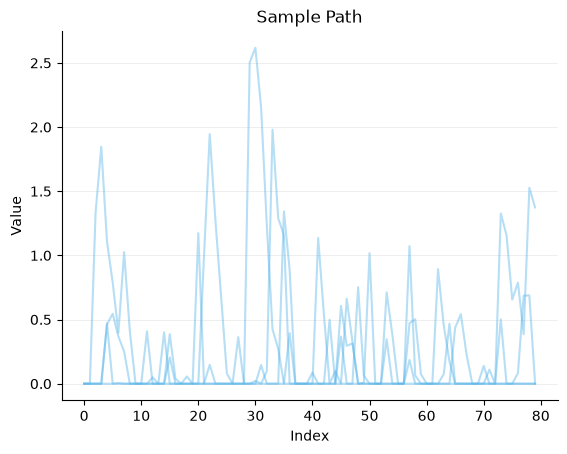

In [5]:
gm1 = GM1(interarrival_dist=Gamma(shape=8, rate=8), service_rate=2)
gm1.sim(4).plot(tmin=0, tmax=80)

## The special case: M/M/1

Exponential gaps between arrivals *are* Poisson arrivals -- that is what the **M** (for
memoryless) stands for in Kendall's notation. So making both distributions exponential gives
the `M/M/1` queue: Poisson arrivals at rate 1 below, and exponential service at rate 2. Any
of the three classes can spell it, since each one is exponential on the side it fixes.

The `MM1` class in `markov_chains.py` models this same queue, but reports the number of
customers in the system at each moment of continuous time rather than each customer's wait --
same queue, different question.

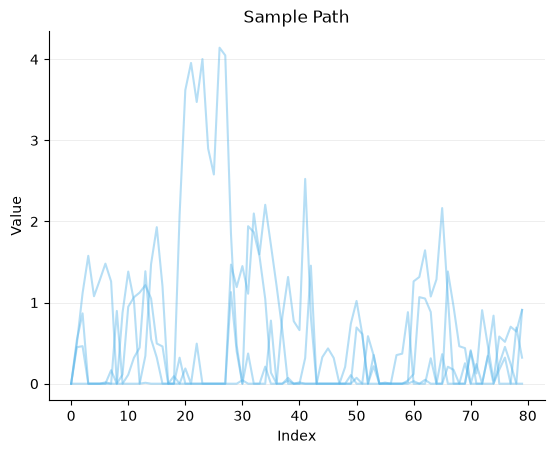

In [6]:
mm1 = GG1(Exponential(rate=1), Exponential(rate=2))
mm1.sim(4).plot(tmin=0, tmax=80)

## One customer's wait

Index the queue at a customer number to get an ordinary random variable, then simulate, plot,
and summarize it as usual. The spike at 0 is the customers who found the server free.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


0.4660389707531564

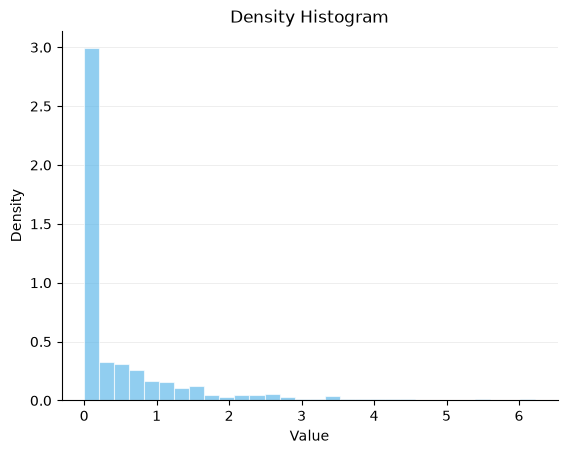

In [7]:
waits = mm1[50].sim(500)
waits.plot()
waits.mean()